##**PROJECT TOPIC :**
### ***A Hybrid NLP Framework for Detecting Depression and Anxiety on Social Platforms***



In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **DATATSET**

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Load dataset
data = pd.read_csv('https://raw.githubusercontent.com/Prinoor/nlp-anxiety-depression-detection/main/Filtered%20data.csv', encoding='latin-1', engine='python')

# Encode target labels - Fit on all unique categories before splitting
label_enc = LabelEncoder()
data['label_encoded'] = label_enc.fit_transform(data['Category'])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    data['Statement'],
    data['label_encoded'],
    test_size=0.2,
    random_state=42
)

### **PREPROCESSING**

In [10]:
data.describe()

,label_encoded
count,19294.000000
mean,0.798746
std,0.401465
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,2.000000


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19294 entries, 0 to 19293
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   S.No.          19292 non-null  object
 1   Statement      19283 non-null  object
 2   Category       19290 non-null  object
 3   label_encoded  19294 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 603.1+ KB


In [12]:
data.shape

(19294, 4)

In [13]:
data.isnull().sum()

,0
S.No.,2
Statement,11
Category,4
label_encoded,0


In [14]:
data.dropna(inplace=True)


In [15]:
data.isnull().sum()

,0
S.No.,0
Statement,0
Category,0
label_encoded,0


In [16]:
data.duplicated().sum()

0

In [17]:
data['Category'].value_counts()

,count
Category,
Depression,15402
Anxiety,3880


In [18]:
#REMOVING MISSPELLED COLUMN
# data['Category'] = data['Category'].replace('status', 'Stress') # This line is not needed based on value counts.

In [19]:
data['Category'].value_counts()

,count
Category,
Depression,15402
Anxiety,3880


In [20]:
data['Statement'] = data['Statement'].str.lower()

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

In [22]:
data.columns

Index(['S.No.', 'Statement', 'Category', 'label_encoded'], dtype='object')

In [23]:
data['Category'].value_counts()

,count
Category,
Depression,15402
Anxiety,3880


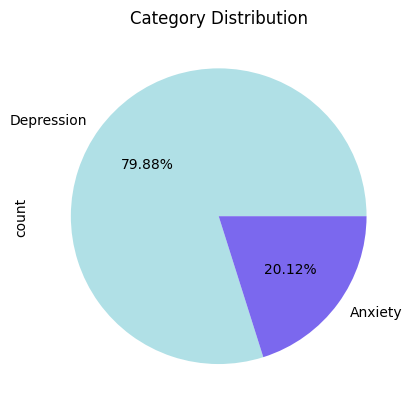

In [24]:
#Pie chart
data['Category'].value_counts().plot(kind='pie', autopct='%.2f%%',colors=['powderblue', 'mediumslateblue', 'salmon', 'palegreen', 'lemonchiffon'])
plt.title('Category Distribution')
plt.show()


In [25]:
import matplotlib.pyplot as plt

model_scores = {}  # Store model name → accuracy

### **MODEL TRAINING**

In [26]:
# Encode target labels
label_enc = LabelEncoder()
data['label_encoded'] = label_enc.fit_transform(data['Category'])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    data['Statement'],
    data['label_encoded'],
    test_size=0.2,
    random_state=42
)

# TF-IDF vectorization for classical ML models
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


/tmp/ipykernel_22879/4246907737.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_words, palette="viridis")


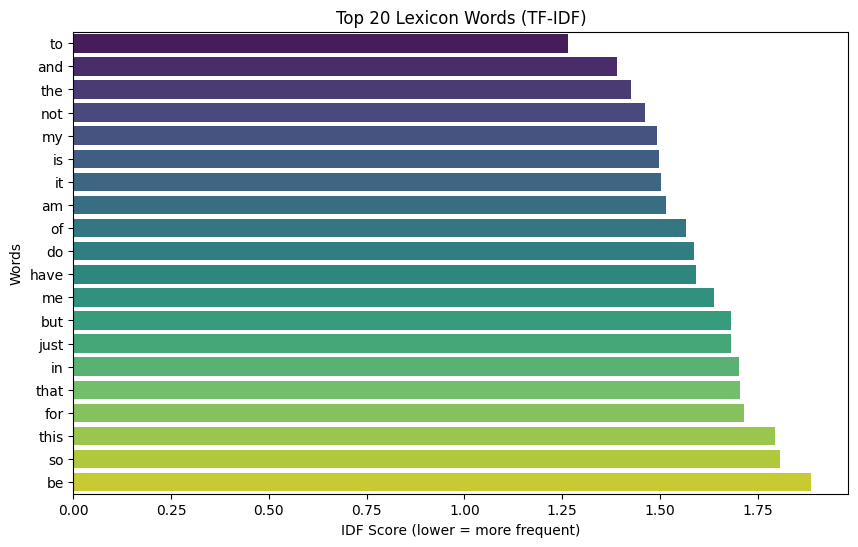

In [27]:
# --- Lexicon Graph (Top TF-IDF Words) ---
import numpy as np

# Get words and their corresponding IDF scores
feature_names = np.array(tfidf.get_feature_names_out())
idf_scores = tfidf.idf_

# Sort words by importance (lower idf = more frequent across documents)
sorted_idx = np.argsort(idf_scores)

# Top 20 words (most informative by TF-IDF)
top_n = 20
top_words = feature_names[sorted_idx[:top_n]]
top_scores = idf_scores[sorted_idx[:top_n]]

plt.figure(figsize=(10,6))
sns.barplot(x=top_scores, y=top_words, palette="viridis")
plt.xlabel("IDF Score (lower = more frequent)")
plt.ylabel("Words")
plt.title(f"Top {top_n} Lexicon Words (TF-IDF)")
plt.show()


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


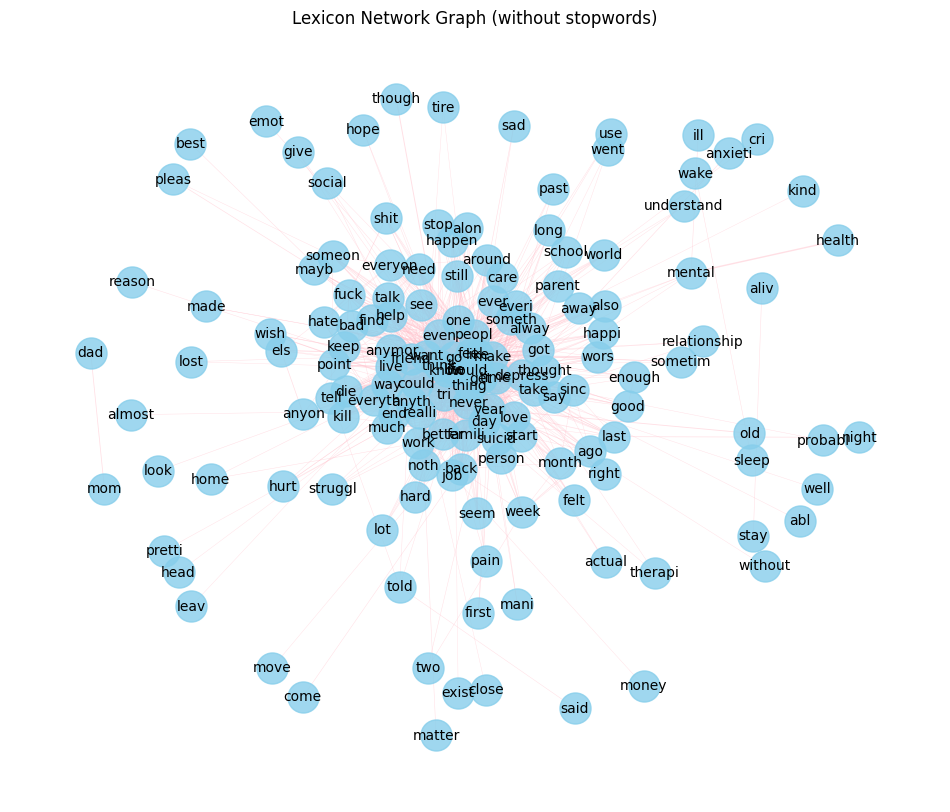

In [28]:
import networkx as nx

import nltk
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download resources if not already
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')  # for lemmatizer
nltk.download('punkt_tab') # Download the missing resource

# Initialize stemmer, lemmatizer, and stopwords
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Custom tokenizer: tokenization + stopword removal + stemming + lemmatization
def stem_lemma_tokenizer(text):
    tokens = word_tokenize(text.lower())  # lowercase + tokenize
    filtered = [t for t in tokens if t.isalpha() and t not in stop_words]  # remove stopwords & non-alphabetic

    # First lemmatize, then stem (you can swap if you want)
    processed = [stemmer.stem(lemmatizer.lemmatize(token)) for token in filtered]
    return processed

# Use custom tokenizer inside TF-IDF
tfidf = TfidfVectorizer(max_features=200, tokenizer=stem_lemma_tokenizer)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)



# Get words
words = tfidf.get_feature_names_out()

# Compute word similarity matrix (cosine similarity between words)
from sklearn.metrics.pairwise import cosine_similarity
word_sim_matrix = cosine_similarity(X_train_tfidf.T)

# Build graph
G = nx.Graph()
for i in range(len(words)):
    for j in range(i+1, len(words)):
        if word_sim_matrix[i, j] > 0.15:  # threshold for edge strength
            G.add_edge(words[i], words[j], weight=word_sim_matrix[i, j])

# Draw graph
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.3)  # layout for visualization
edges = G.edges(data=True)

# Edge weights
weights = [edata['weight']*2 for _,_,edata in edges]

nx.draw_networkx_nodes(G, pos, node_size=500, node_color="skyblue", alpha=0.8)
nx.draw_networkx_edges(G, pos, width=weights, edge_color="pink", alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=10, font_family="sans-serif")

plt.title("Lexicon Network Graph (without stopwords)")
plt.axis("off")
plt.show()

In [29]:
data.sample(5)

,S.No.,Statement,Category,label_encoded
15413,15411,i came to this conclusion tonight. can someone...,Depression,1
11580,11578,"decided to not kill myself today, and i am goi...",Depression,1
13049,13047,all i needed was 1 or 2 people who actually ga...,Depression,1
15191,15189,why is it so expensive to seek help? i am brok...,Depression,1
10999,10997,"i had a friend who dated this guy, who would n...",Depression,1


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []   # to store metrics for final table
model_scores = {}  # to store only accuracy for plotting

for name, model in models.items():
    # Train
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)

    # Metrics
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted')
    rec = recall_score(y_test, preds, average='weighted')
    f1 = f1_score(y_test, preds, average='weighted')

    # Save
    model_scores[name] = acc
    results.append([name, acc, prec, rec, f1])

    # Print nicely
    print(f"\n{name}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1 Score : {f1:.4f}")

# Convert to DataFrame for final table
df_results = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
print("\nOverall Comparison:")
print(df_results)


Logistic Regression
  Accuracy : 0.9367
  Precision: 0.9375
  Recall   : 0.9367
  F1 Score : 0.9371

Random Forest
  Accuracy : 0.9341
  Precision: 0.9344
  Recall   : 0.9341
  F1 Score : 0.9343

SVM
  Accuracy : 0.9398
  Precision: 0.9423
  Recall   : 0.9398
  F1 Score : 0.9407

KNN
  Accuracy : 0.5642
  Precision: 0.8324
  Recall   : 0.5642
  F1 Score : 0.5999

Overall Comparison:
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.936738   0.937491  0.936738  0.937071
1        Random Forest  0.934146   0.934413  0.934146  0.934273
2                  SVM  0.939850   0.942337  0.939850  0.940736
3                  KNN  0.564169   0.832431  0.564169  0.599941


In [31]:
import ml_dtypes
import tensorflow as tf

print("ml_dtypes:", ml_dtypes.__version__)
print("TensorFlow:", tf.__version__)

ml_dtypes: 0.3.1
TensorFlow: 2.16.2


In [32]:
import transformers
import keras
import tensorflow as tf

print("Transformers:", transformers.__version__)
print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

Transformers: 4.36.2
TensorFlow: 2.16.2
Keras: 3.0.5


In [33]:
import numpy as np
import random
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# -------------------------
# Reproducibility (important)
# -------------------------
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

# -------------------------
# Tokenization
# -------------------------
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_train),
    maxlen=100
)

X_test_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_test),
    maxlen=100
)

# -------------------------
# LSTM Model (Keras 3 FIX: no input_length)
# -------------------------
model_lstm = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim=5000,
        output_dim=128
    ),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(len(label_enc.classes_), activation="softmax")
])

model_lstm.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# -------------------------
# Train
# -------------------------
model_lstm.fit(
    X_train_seq,
    y_train,
    epochs=3,
    batch_size=32,
    validation_split=0.1
)

# -------------------------
# Predict
# -------------------------
y_pred_probs = model_lstm.predict(X_test_seq)
y_pred = np.argmax(y_pred_probs, axis=1)

# -------------------------
# Metrics
# -------------------------
acc = accuracy_score(y_test, y_pred)

prec = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

rec = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("LSTM")
print(f"  Accuracy : {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall   : {rec:.4f}")
print(f"  F1 Score : {f1:.4f}")

# -------------------------
# Save results
# -------------------------
model_scores["LSTM"] = acc
results.append(["LSTM", acc, prec, rec, f1])

Epoch 1/3
434/434 ━━━━━━━━━━━━━━━━━━━━ 31s 66ms/step - accuracy: 0.9227 - loss: 0.2221 - val_accuracy: 0.9760 - val_loss: 0.0807
Epoch 2/3
434/434 ━━━━━━━━━━━━━━━━━━━━ 29s 67ms/step - accuracy: 0.9772 - loss: 0.0674 - val_accuracy: 0.9689 - val_loss: 0.0846
Epoch 3/3
434/434 ━━━━━━━━━━━━━━━━━━━━ 26s 61ms/step - accuracy: 0.9851 - loss: 0.0438 - val_accuracy: 0.9650 - val_loss: 0.1215
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
LSTM
  Accuracy : 0.9679
  Precision: 0.9681
  Recall   : 0.9679
  F1 Score : 0.9679


In [34]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [35]:
!pip install -U --no-cache-dir \
tensorflow==2.16.2 \
keras==3.0.5 \
tf-keras==2.16.0 \
transformers==4.36.2 \
ml-dtypes==0.3.1

In [36]:
import numpy as np
import torch
from transformers import DistilBertTokenizer, DistilBertModel

tokenizer_bert = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

bert_model = DistilBertModel.from_pretrained("distilbert-base-uncased")
bert_model.eval()

def get_bert_embeddings(texts, batch_size=32):
    all_embeddings = []

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]

            encodings = tokenizer_bert(
                batch_texts.tolist(),
                padding=True,
                truncation=True,
                max_length=64,
                return_tensors="pt"
            )

            outputs = bert_model(**encodings)

            embeddings = outputs.last_hidden_state[:, 0, :]

            all_embeddings.append(embeddings.numpy())

    return np.vstack(all_embeddings)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [37]:
# takes
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Assuming your dataframe is called df with columns 'Statement' and 'Category'
X = data['Statement']
y = data['Category']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


### **EVALUATION**

In [38]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

stacking_model = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=500)),
        ('rf', RandomForestClassifier(n_estimators=100, n_jobs=-1)),
        ('svc', LinearSVC())
    ],
    final_estimator=LogisticRegression(max_iter=500),
    n_jobs=-1
)

stacking_model.fit(X_train_tfidf, y_train)
stack_preds = stacking_model.predict(X_test_tfidf)
acc = accuracy_score(y_test, stack_preds)
model_scores["Stacking Ensemble"] = acc
print("Stacking Ensemble Accuracy:", acc)


Stacking Ensemble Accuracy: 0.96577651024112


In [39]:
import numpy as np
print(np.__version__)

1.26.4


In [40]:
!pip install numpy==1.26.4 tensorflow==2.16.2 keras==3.0.5 tf-keras==2.16.0 transformers==4.36.2 lime

In [41]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from lime.lime_text import LimeTextExplainer

# Load dataset
data = pd.read_csv('https://raw.githubusercontent.com/Prinoor/nlp-anxiety-depression-detection/main/Filtered%20data.csv', encoding='latin-1', engine='python')
data.dropna(inplace=True) # Ensure data is clean as in preprocessing cells

# Encode target labels - Fit on all unique categories before splitting
label_enc = LabelEncoder()
data['label_encoded'] = label_enc.fit_transform(data['Category'])

# Split data (re-doing for self-contained cell)
X_train, X_test, y_train, y_test = train_test_split(
    data['Statement'],
    data['label_encoded'],
    test_size=0.2,
    random_state=42
)

# Initialize and fit label_enc for LIME explainer
# This was already added, but now 'data' is available
explainer = LimeTextExplainer(class_names=label_enc.classes_)

i = 0

tfidf_explainer = TfidfVectorizer(max_features=5000)
tfidf_explainer.fit(X_train)

lr_explainer = LogisticRegression(max_iter=1000)
lr_explainer.fit(tfidf_explainer.transform(X_train), y_train)

exp = explainer.explain_instance(
    X_test.iloc[i],
    classifier_fn=lambda x: lr_explainer.predict_proba(tfidf_explainer.transform(x))
)

exp.show_in_notebook()

In [42]:
import warnings
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import numpy as np
import torch
from transformers import DistilBertTokenizer, DistilBertModel
from sklearn.linear_model import LogisticRegression

# Filter out the specific FutureWarning from huggingface_hub
warnings.filterwarnings("ignore", category=FutureWarning, module="huggingface_hub")

results = []  # To store all model results

print("Initializing DistilBERT tokenizer and model...")
# Initialize BERT tokenizer and model (moved from previous cell to ensure definition)
tokenizer_bert = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
bert_model = DistilBertModel.from_pretrained("distilbert-base-uncased")
bert_model.eval()
print("DistilBERT model loaded.")

# Define get_bert_embeddings function (moved from previous cell to ensure definition)
def get_bert_embeddings(texts, batch_size=32):
    all_embeddings = []

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]

            encodings = tokenizer_bert(
                batch_texts.tolist(),
                padding=True,
                truncation=True,
                max_length=64,
                return_tensors="pt"
            )

            outputs = bert_model(**encodings)

            embeddings = outputs.last_hidden_state[:, 0, :]

            all_embeddings.append(embeddings.numpy())

    return np.vstack(all_embeddings)

print("Generating DistilBERT embeddings for training data...")
# DistilBERT embeddings (batch processed)
X_train_bert = get_bert_embeddings(X_train, batch_size=16)
print("Generating DistilBERT embeddings for test data...")
X_test_bert  = get_bert_embeddings(X_test, batch_size=16)
print("Embeddings generated.")

print("Training Logistic Regression model...")
# Example: Logistic Regression on BERT embeddings
lr = LogisticRegression(max_iter=200)
lr.fit(X_train_bert, y_train)
y_pred_lr = lr.predict(X_test_bert)
print("Logistic Regression model trained and predictions made.")

# Metrics for DistilBERT + Logistic Regression
acc = accuracy_score(y_test, y_pred_lr)
prec = precision_score(y_test, y_pred_lr, average='weighted')
rec = recall_score(y_test, y_pred_lr, average='weighted')
f1 = f1_score(y_test, y_pred_lr, average='weighted')

print("\nDistilBERT + Logistic Regression")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

# Save results consistently
# Check if model_scores is defined, if not, initialize it
if 'model_scores' not in locals():
    model_scores = {}
model_scores["DistilBERT + LR"] = acc   # only accuracy for plotting

# Check if results is defined and is a list, if not, initialize it
if 'results' not in locals() or not isinstance(results, list):
    results = []
results.append(["DistilBERT + Logistic Regression", acc, prec, rec, f1])  # full metrics for table


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


DistilBERT + Logistic Regression
Accuracy : 0.9671
Precision: 0.9675
Recall   : 0.9671
F1 Score : 0.9673
Confusion Matrix:
 [[ 717   52]
 [  75 3013]]


### **RESULTS**


Overall Model Comparison:
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.963702   0.964624  0.963702  0.964028
1        Random Forest  0.952813   0.953168  0.952813  0.952972
2                  SVM  0.967851   0.969342  0.967851  0.968282
3                  KNN  0.294789   0.833816  0.294789  0.244037


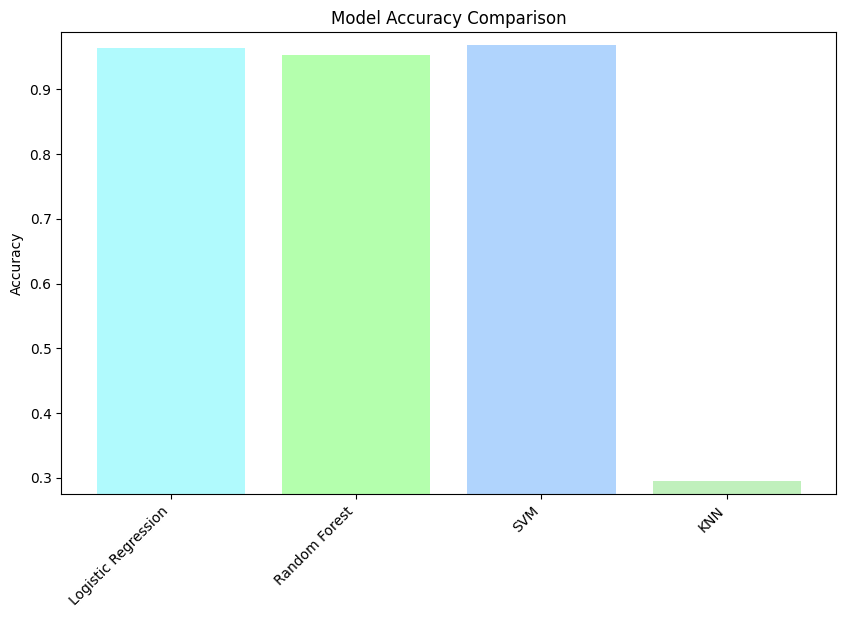

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

results = []        # all metrics for final table
model_scores = {}   # only accuracy for plotting

# --- Classical Models Evaluation ---
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)

    # Metrics
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted')
    rec = recall_score(y_test, preds, average='weighted')
    f1 = f1_score(y_test, preds, average='weighted')

    # Save for table + plotting
    results.append([name, acc, prec, rec, f1])
    model_scores[name] = acc

# --- Add LSTM and DistilBERT results if you already computed them ---
# results.append(["LSTM", lstm_acc, lstm_prec, lstm_rec, lstm_f1])
# results.append(["DistilBERT + LR", bert_acc, bert_prec, bert_rec, bert_f1])
# model_scores["LSTM"] = lstm_acc
# model_scores["DistilBERT + LR"] = bert_acc

# --- Final Results Table ---
df_results = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
print("\nOverall Model Comparison:")
print(df_results)

# --- Final Comparison Plot with Pastel Colors ---
plt.figure(figsize=(10, 6))

# Custom pastel palette
colors = ["#B0FAFD", "#B4FFAD", "#B0D4FD", "#C0F0BC", "#A09BFD", "#9DFBDC"]

# Plot bars (order preserved)
bar_colors = [colors[i % len(colors)] for i in range(len(model_scores))]
plt.bar(model_scores.keys(), model_scores.values(), color=bar_colors)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=45, ha='right')

# Zoom in so differences are visible
min_acc = min(model_scores.values())
max_acc = max(model_scores.values())
plt.ylim(min_acc - 0.02, max_acc + 0.02)

plt.show()


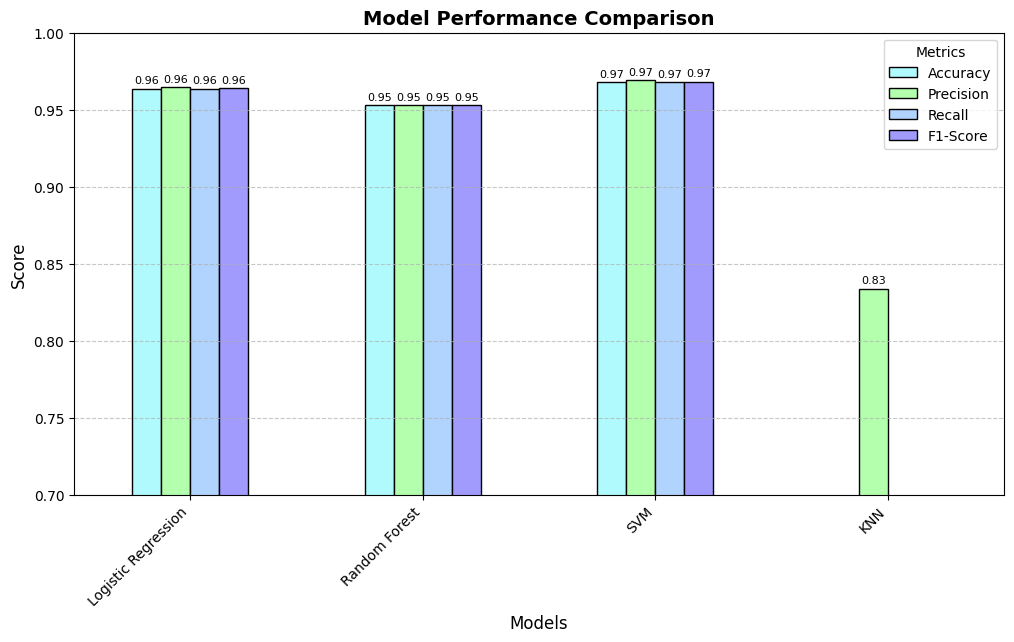

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Convert results into DataFrame (from model_scores dict)
df_results = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])
df_results = df_results.set_index("Model")

# Plot grouped bars
ax = df_results.plot(kind="bar", figsize=(12, 6),
                     color=["#B0FAFD", "#B4FFAD", "#B0D4FD", "#A09BFD"],
                     edgecolor="black")

plt.title("Model Performance Comparison", fontsize=14, weight="bold")
plt.ylabel("Score", fontsize=12)
plt.xlabel("Models", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0.7, 1.0)  # adjust depending on your results

# Add legend
plt.legend(title="Metrics", fontsize=10)

# Add grid for readability
plt.grid(axis="y", linestyle="--", alpha=0.7)

# ---- Add value labels on top of bars ----
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge", fontsize=8, padding=2)

plt.show()

In [45]:

# Create DataFrame from results list
df_results1 = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])

# Print table nicely
print("\nOverall Model Comparison:")
print(df_results1.to_string(index=False))



Overall Model Comparison:
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.963702   0.964624 0.963702  0.964028
      Random Forest  0.952813   0.953168 0.952813  0.952972
                SVM  0.967851   0.969342 0.967851  0.968282
                KNN  0.294789   0.833816 0.294789  0.244037


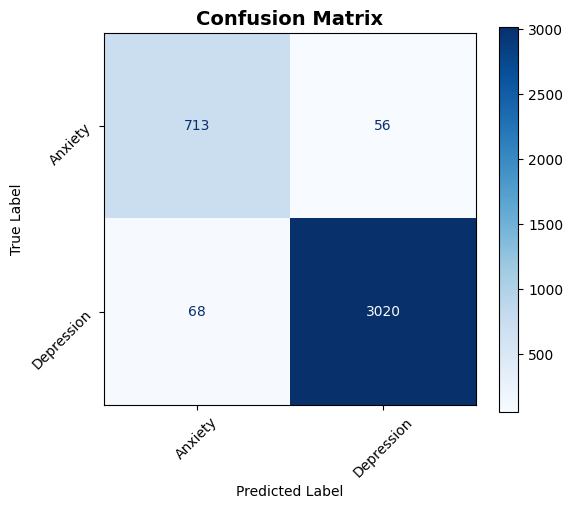

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
# y_test contains numerical labels and y_pred (from LSTM) also contains numerical labels.
# We will use these directly for the confusion matrix.
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix using sklearn helper
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_enc.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=True)

plt.title("Confusion Matrix", fontsize=14, weight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

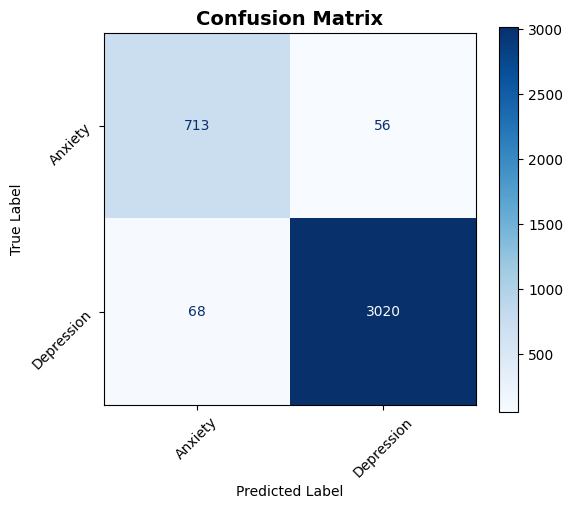

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
# y_test contains numerical labels and y_pred (from LSTM) also contains numerical labels.
# We will use these directly for the confusion matrix.
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix using sklearn helper
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_enc.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=True)

plt.title("Confusion Matrix", fontsize=14, weight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

_______________________________________________

**Explanation of the code:**

1.  **Import Libraries:** Import necessary libraries, including `shap`, `torch`, and components from `transformers`.
2.  **Load Model and Tokenizer:** Load the DistilBERT tokenizer and the `DistilBertForSequenceClassification` model from Hugging Face, ensuring you specify the number of labels (`num_labels`) based on your dataset. The model is set to evaluation mode (`model.eval()`).
3.  **Label Encoding:** Re-initialize and fit a `LabelEncoder` on all unique categories from your original data (`data['Category'].unique()`) to ensure it can handle all possible output classes. Then, transform your test sample labels.
4.  **`predict_proba_torch` Function:** Define a function that takes a list of text strings as input, tokenizes them using the DistilBERT tokenizer, passes them through the PyTorch model, and returns the predicted probabilities for each class using `softmax`. This function is designed to be compatible with SHAP's explainers.
5.  **Select Subset:** Choose a small subset of your test data (`X_test_sample_subset`) for explainability, as SHAP calculations can be computationally intensive, especially with larger datasets or models.
6.  **Create SHAP Explainer:** Initialize a `shap.KernelExplainer`. This explainer works by approximating SHAP values and can be used with any model as long as you provide a prediction function (`predict_proba_torch`) and a background dataset (the subset of test data in this case).
7.  **Choose Instance and Calculate SHAP Values:** Select a specific text instance from the subset that you want to explain. Calculate the SHAP values for this instance using the explainer.
8.  **Visualize Explanation:** Use `shap.initjs()` to enable JavaScript visualizations in the notebook and `shap.force_plot()` to visualize the explanation for the chosen instance. The `force_plot` shows how each word in the input contributes to the model's prediction for a specific class. We also map the predicted label back to its original category name for clarity.